In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("C:/Users/ary53/Downloads/AirPassengers.csv")

print(df.head())

print(df.info())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


In [3]:
df.rename(columns={"#Passengers":"Passengers"}, inplace=True)

df["Month"] = pd.to_datetime(df["Month"])

df.set_index("Month", inplace=True)

print(df.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


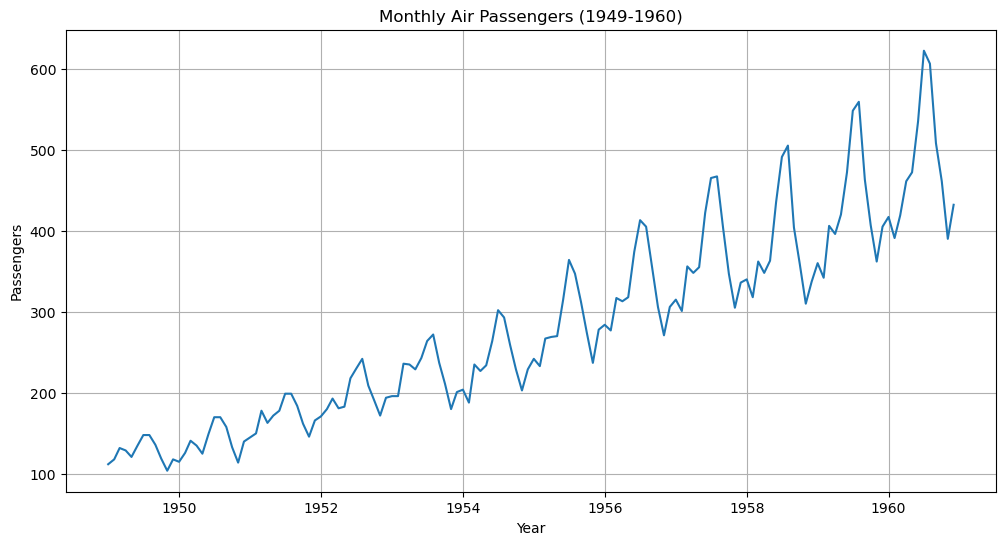

In [4]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Passengers"])

plt.title("Monthly Air Passengers (1949-1960)")

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.grid(True)

plt.show()

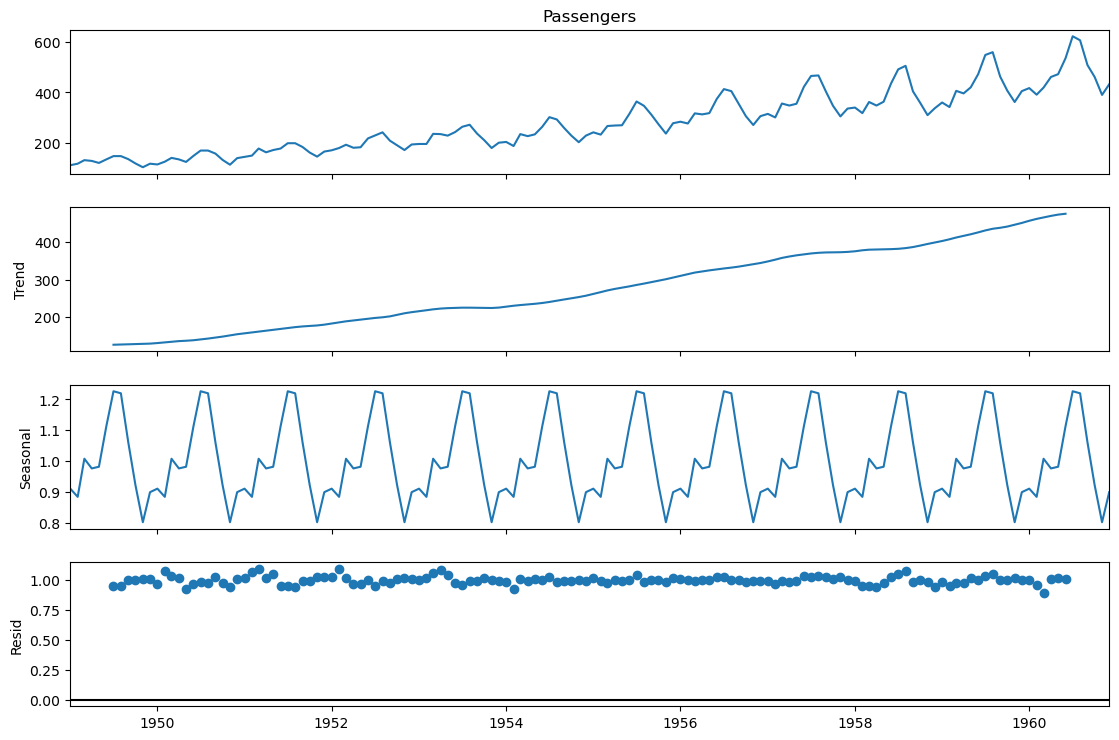

In [5]:
decomposition = seasonal_decompose(df["Passengers"],
                                   model="multiplicative",
                                   period=12)

fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.show()

In [6]:
df["MA_6"] = df["Passengers"].rolling(window=6).mean()

In [7]:
df["MA_12"] = df["Passengers"].rolling(window=12).mean()

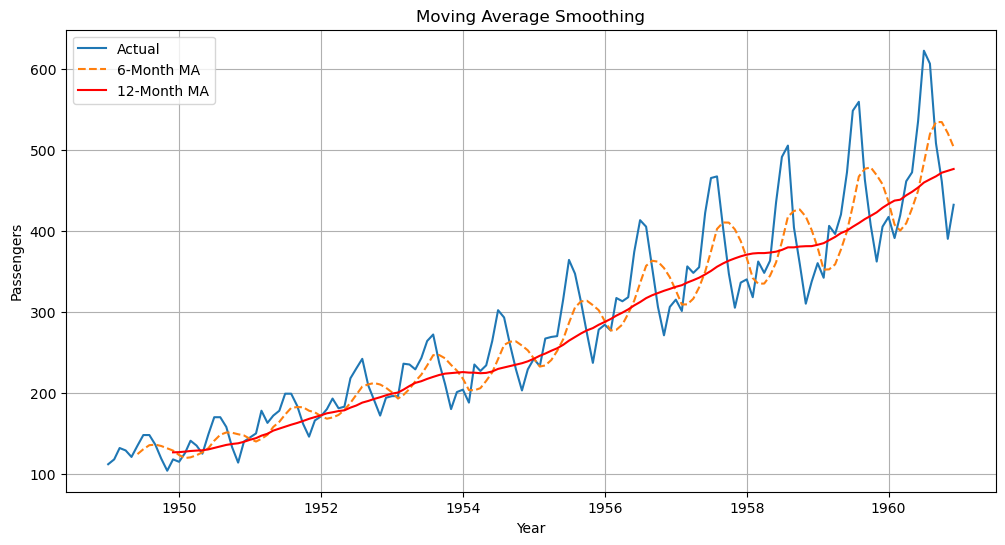

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df.index,
         df["Passengers"],
         label="Actual")

plt.plot(df.index,
         df["MA_6"],
         linestyle="--",
         label="6-Month MA")

plt.plot(df.index,
         df["MA_12"],
         color="red",
         label="12-Month MA")

plt.title("Moving Average Smoothing")

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.legend()

plt.grid(True)

plt.show()

In [9]:
train = df.iloc[:-12]

test = df.iloc[-12:]

In [10]:
model = SARIMAX(train["Passengers"],
                order=(2,1,1),
                seasonal_order=(1,1,1,12))

result = model.fit()

C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ary53\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\ary53\AppData\Local\anaconda3\Lib\site

In [11]:
forecast = result.forecast(steps=12)

In [12]:
rmse = np.sqrt(mean_squared_error(test["Passengers"],
                                  forecast))

print("RMSE:", rmse)

RMSE: 21.16927589061486


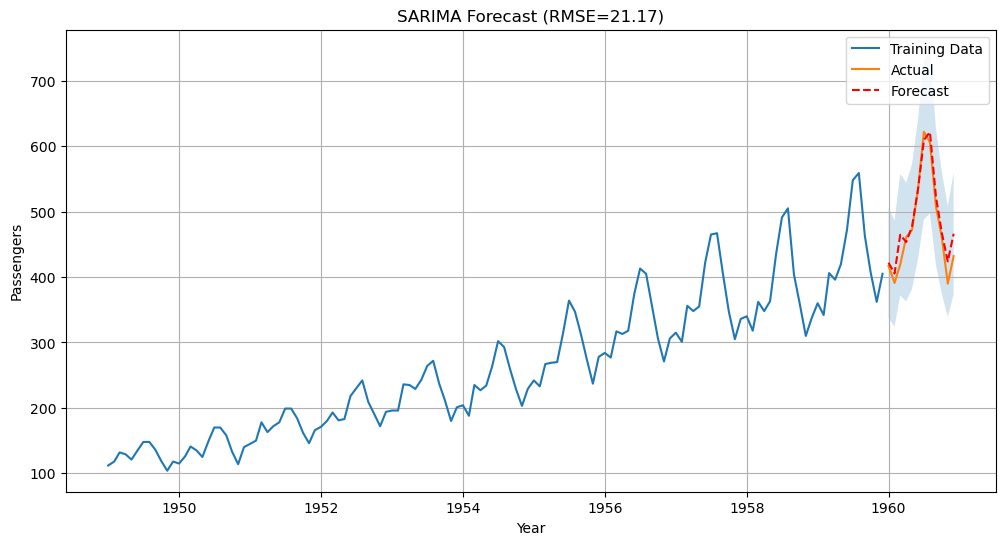

In [13]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train["Passengers"],
         label="Training Data")

plt.plot(test.index,
         test["Passengers"],
         label="Actual")

plt.plot(test.index,
         forecast,
         color="red",
         linestyle="--",
         label="Forecast")

plt.fill_between(test.index,
                 forecast*0.8,
                 forecast*1.2,
                 alpha=0.2)

plt.title(f"SARIMA Forecast (RMSE={rmse:.2f})")

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.legend()

plt.grid(True)

plt.show()